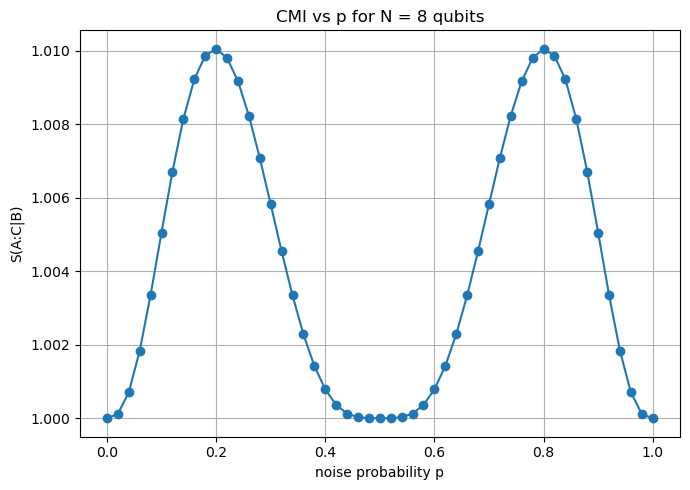

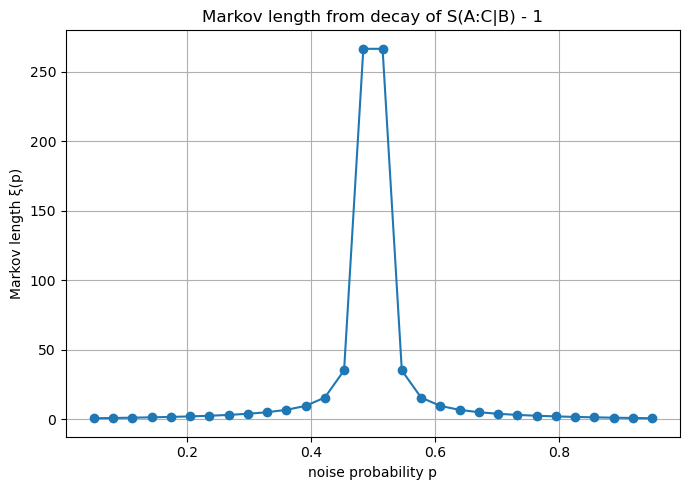

p values for Markov length:
[0.05       0.08103448 0.11206897 0.14310345 0.17413793 0.20517241
 0.2362069  0.26724138 0.29827586 0.32931034 0.36034483 0.39137931
 0.42241379 0.45344828 0.48448276 0.51551724 0.54655172 0.57758621
 0.60862069 0.63965517 0.67068966 0.70172414 0.73275862 0.7637931
 0.79482759 0.82586207 0.85689655 0.88793103 0.91896552 0.95      ]

Markov length xi(p):
[  0.56370124   0.75598175   0.96998696   1.21996343   1.52092272
   1.89216842   2.36081359   2.967512     3.77799903   4.91006933
   6.60661524   9.47267495  15.48590939  35.00399184 266.65713326
 266.65715266  35.00399181  15.48590939   9.47267495   6.60661524
   4.91006933   3.77799903   2.967512     2.36081359   1.89216842
   1.52092272   1.21996343   0.96998696   0.75598175   0.56370125]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, log2


# ============================================================
# User settings
# ============================================================

# Fixed system size for the first plot: CMI vs p
# Must be at least 4.
N_FIXED = 8

# Distances used for extracting the Markov length.
# Here d is the distance between A and C.
DISTANCES = np.arange(1, 10)  # d = 1, 2, ..., 6

# p values for CMI plot
P_VALUES_CMI = np.linspace(0.0, 1.0, 51)

# p values for Markov length plot
# Avoid p = 0 and p = 1 because the decay fit becomes singular there.
P_VALUES_MARKOV = np.linspace(0.05, 0.95, 30)


# ============================================================
# Basic entropy helper
# ============================================================

def safe_xlog2x(x):
    """
    Computes x log2(x), with the convention 0 log 0 = 0.
    This avoids numerical errors when x is very close to zero.
    """
    if x <= 0.0:
        return 0.0
    return x * log2(x)


# ============================================================
# Entropy of reduced subsystems of noisy GHZ
# ============================================================

def entropy_proper_subsystem(k, p):
    """
    Entropy of any proper subsystem of size k.

    We start with an N-qubit GHZ state and apply independent X noise:

        rho -> (1 - p) rho + p X rho X

    to every qubit.

    For any proper subsystem, the reduced density matrix is diagonal in the
    computational basis. The probability only depends on the Hamming weight w.
    """
    entropy = 0.0

    for w in range(k + 1):
        # Probability of any bitstring with Hamming weight w.
        prob_w = 0.5 * (
            p**w * (1 - p)**(k - w)
            +
            p**(k - w) * (1 - p)**w
        )

        # Number of bitstrings with Hamming weight w.
        degeneracy = comb(k, w)

        entropy -= degeneracy * safe_xlog2x(prob_w)

    return entropy


def entropy_full_noisy_ghz(N, p):
    """
    Entropy of the full N-qubit noisy GHZ state.

    The X-noise maps the GHZ state into a mixture of orthogonal GHZ-like
    cat states:

        (|e> + |e_bar>) / sqrt(2)

    where e is a bit-flip error string.
    """
    entropy = 0.0

    for w in range(N // 2 + 1):
        # Probability of the pair {e, e_bar}
        pair_prob = (
            p**w * (1 - p)**(N - w)
            +
            p**(N - w) * (1 - p)**w
        )

        # Number of independent cat states with this weight.
        if N % 2 == 0 and w == N // 2:
            degeneracy = comb(N, w) / 2
        else:
            degeneracy = comb(N, w)

        entropy -= degeneracy * safe_xlog2x(pair_prob)

    return entropy


# ============================================================
# Conditional mutual information
# ============================================================

def cmi_noisy_ghz(N, p):
    """
    Computes S(A:C|B) for the noisy GHZ state.

    We take:
        A = one qubit
        C = one qubit
        B = all remaining N - 2 qubits

    Then:

        S(A:C|B) = S(AB) + S(BC) - S(B) - S(ABC)

    Since the state is permutation-symmetric under X noise:

        |AB| = N - 1
        |BC| = N - 1
        |B|  = N - 2
        |ABC| = N
    """
    S_AB = entropy_proper_subsystem(N - 1, p)
    S_BC = entropy_proper_subsystem(N - 1, p)
    S_B = entropy_proper_subsystem(N - 2, p)
    S_ABC = entropy_full_noisy_ghz(N, p)

    return S_AB + S_BC - S_B - S_ABC


# ============================================================
# Distance convention
# ============================================================

def total_qubits_from_distance(d):
    """
    Converts distance d between A and C into total system size N.

    This follows your earlier choice:

        A = qubit 1
        C = qubit N/2

    Therefore:

        d = C - A = N/2 - 1

    so:

        N = 2(d + 1)
    """
    return 2 * (d + 1)


# ============================================================
# Markov length extraction
# ============================================================

def fit_markov_length(distances, cmi_values):
    """
    Extracts Markov length xi from the decay:

        S(A:C|B) - 1 ≈ a exp(-d / xi)

    Taking the logarithm gives:

        log(S(A:C|B) - 1) ≈ log(a) - d / xi

    Therefore, if the fitted slope is m, then:

        m = -1 / xi

    so:

        xi = -1 / m
    """
    excess_cmi = np.array(cmi_values) - 1.0

    # Keep only positive values, because we will take a logarithm.
    mask = excess_cmi > 1e-14

    if np.sum(mask) < 2:
        return np.nan

    x = np.array(distances)[mask]
    y = np.log(excess_cmi[mask])

    # Linear fit: y = intercept + slope * x
    slope, intercept = np.polyfit(x, y, 1)

    if slope >= 0:
        return np.nan

    xi = -1.0 / slope
    return xi


# ============================================================
# Plot 1: CMI as a function of p for one fixed system size
# ============================================================

cmi_fixed_N = []

for p in P_VALUES_CMI:
    cmi_fixed_N.append(cmi_noisy_ghz(N_FIXED, p))

plt.figure(figsize=(7, 5))
plt.plot(P_VALUES_CMI, cmi_fixed_N, marker="o")
plt.xlabel("noise probability p")
plt.ylabel("S(A:C|B)")
plt.title(f"CMI vs p for N = {N_FIXED} qubits")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# Plot 2: Markov length xi as a function of p
# ============================================================

xi_values = []

for p in P_VALUES_MARKOV:
    cmi_vs_distance = []

    for d in DISTANCES:
        N = total_qubits_from_distance(d)
        cmi = cmi_noisy_ghz(N, p)
        cmi_vs_distance.append(cmi)

    xi = fit_markov_length(DISTANCES, cmi_vs_distance)
    xi_values.append(xi)

plt.figure(figsize=(7, 5))
plt.plot(P_VALUES_MARKOV, xi_values, marker="o")
plt.xlabel("noise probability p")
plt.ylabel("Markov length ξ(p)")
plt.title("Markov length from decay of S(A:C|B) - 1")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# Optional: print numerical values
# ============================================================

print("p values for Markov length:")
print(P_VALUES_MARKOV)

print("\nMarkov length xi(p):")
print(np.array(xi_values))